In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
from scipy import stats
from glob import glob
import torch.nn.functional as F
import torch
import datetime, os

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, f1_score

#sns.set_theme(style="whitegrid")

[W924 15:45:51.719500377 OperatorEntry.cpp:154] Warning: Warning only once for all operators,  other operators may also be overridden.
  Overriding a previously registered kernel for the same operator and the same dispatch key
  operator: aten::_validate_compressed_sparse_indices(bool is_crow, Tensor compressed_idx, Tensor plain_idx, int cdim, int dim, int nnz) -> ()
    registered at /pytorch/build/aten/src/ATen/RegisterSchema.cpp:6
  dispatch key: XPU
  previous kernel: registered at /pytorch/build/aten/src/ATen/RegisterCPU.cpp:30477
       new kernel: registered at /build/intel-pytorch-extension/build/Release/csrc/gpu/csrc/aten/generated/ATen/RegisterXPU.cpp:468 (function operator())


In [2]:
FILTER_SE_GENES = False # filter for only genes with SE events
FILTER_EVENT_GENES = False # filter for genes with SE or AR events
SINGLE_COUNT_GENES = True # average out predictions per gene_id
HURDLE_SEPARATION = False # separate 1 values from the rest of the psi predictions
NORMALISED_SCORES = False # show uncorrected scores when they were z-score normalised
BOTH_CELL_LINES = False # separate predictions for both cell lines

In [3]:
def get_predictions(date_folder):
    # find .csv file in the date folder
    # first find the day folder where the exact model folder is located
    day_folder = date_folder[:10]  # e.g., '2025-07-25'
    csv_files = [f for f in glob(f"../trained_models/{day_folder}/{date_folder}/*.csv") if not f.endswith('losses.csv')]
    loss_file = [f for f in glob(f"../trained_models/{day_folder}/{date_folder}/*losses.csv")][0]
    losses = pd.read_csv(loss_file)
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {date_folder}")
    if len(csv_files) == 1:
        return pd.read_csv(csv_files[0]), losses
    else:
        all_predictions = []
        for pred_file in csv_files:
            df = pd.read_csv(pred_file)
            #if 'Unnamed: 0' in df.columns:
            #    df = df.drop(columns=['Unnamed: 0'])
            all_predictions.append(df)
        return pd.concat(all_predictions, ignore_index=True), losses
    
def find_folder(date_folder):
        # if date_folder is 'newest', find the most recent date folder
    if date_folder == 'newest':
        directory = "../trained_models/"
        newest_day = max([os.path.join(directory,d) for d in os.listdir(directory)], key=os.path.getmtime)
        newest_model = max([os.path.join(newest_day, d) for d in os.listdir(newest_day)], key=os.path.getmtime)
        date_folder = newest_model.split('/')[-1]
    print(f"Using date folder: {date_folder}")
    return date_folder


In [4]:
date_folder = find_folder('2025-06-30-16-55')

predictions, losses = get_predictions(date_folder)
predictions = predictions.rename(columns={'Unnamed: 0': 'gene_id', 'Pred': 'PredExpr', 'actual': 'ActualExpr'})
predictions

Using date folder: 2025-06-30-16-55


,gene_id,PredExpr,ActualExpr,PredPsi,ActualPsi,fold_idx
0,ENSG00000196388,1.397516,-0.823909,0.942808,1.0,1
1,ENSG00000164051,1.308474,1.109916,0.912360,1.0,1
2,ENSG00000064102,1.753818,1.707059,0.883961,1.0,1
3,ENSG00000064102,1.703197,1.707059,0.887796,1.0,1
4,ENSG00000064102,1.764012,1.707059,0.842362,1.0,1
...,...,...,...,...,...,...
2480,ENSG00000106397,1.625397,1.317646,0.877622,1.0,1
2481,ENSG00000106397,1.627074,1.317646,0.915886,1.0,1
2482,ENSG00000106397,1.589247,1.317646,0.885427,1.0,1
2483,ENSG00000134769,-0.361472,0.045323,0.976688,1.0,1


## Multitask predictions

In [5]:
if FILTER_SE_GENES:
    # filter predictions to the ones we have SE events for
    se_events = pd.read_csv('../data/psi_response.csv')
    se_events = se_events[se_events['event_id'].str.contains(';SE:')]
    se_genes = set(se_events['gene_id'].unique())

    # filter down predictions to only those genes
    predictions_filtered = predictions[predictions['gene_id'].isin(se_genes)]
    len(predictions_filtered)

if FILTER_EVENT_GENES:
    se_events = pd.read_csv('../data/psi_response.csv')
    se_events = set(se_events['gene_id'].unique())
    print(len(se_events), "genes with SE or AR events")

    predictions_filtered = predictions[predictions['gene_id'].isin(se_events)]
    print(len(predictions_filtered), "predictions for genes with SE or AR events")

In [6]:
if SINGLE_COUNT_GENES:
    # filter the predictions such that for one gene, we average out the predictions
    if FILTER_SE_GENES:
        predictions_filtered = predictions_filtered.groupby('gene_id').mean().reset_index()
    else:
        predictions_filtered = predictions.drop_duplicates(subset=['gene_id'], keep='first')

In [7]:
if not FILTER_SE_GENES and not SINGLE_COUNT_GENES and not FILTER_EVENT_GENES:
    predictions_filtered = predictions

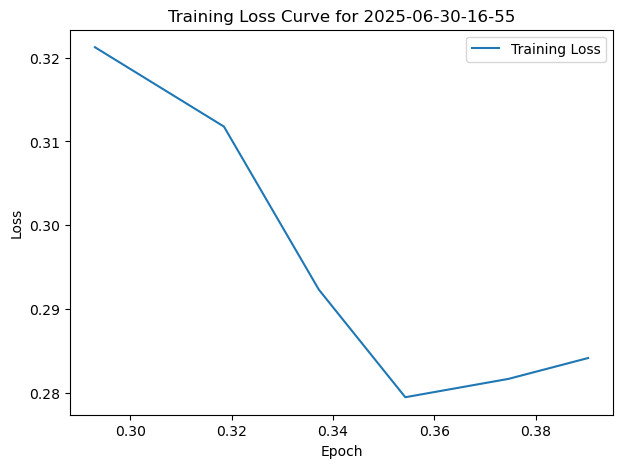

In [8]:
# plot loss curve
# cols: fold,epoch,training_loss,train_expr_loss,train_splice_loss,val_mse,val_r2,val_loss,val_expr,val_splice
plt.figure(figsize=(7, 5))
plt.plot(losses['epoch'], losses['training_loss'], label='Training Loss')
try:
    plt.plot(losses['epoch'], losses['val_loss'], label='Validation Loss')
except:
    pass
plt.xlabel('Epoch')
plt.ylabel('Loss')
# plt.yscale('log')  # Use logarithmic scale for better visibility
plt.title(f'Training Loss Curve for {date_folder}')
plt.legend()
plt.show()

In [9]:
def plot_predictions(predictions, cell_line, pred_col, actual_col):
    pearsonR, _ = stats.pearsonr(predictions[pred_col], predictions[actual_col])
    r2_value = r2_score(predictions[actual_col], predictions[pred_col])
    plt.figure(figsize=(6,6))
    ax = sns.jointplot(
        data=predictions,
        x=pred_col,
        y=actual_col,
        kind = 'scatter',
        joint_kws={'marker':'o', 's':10, 'alpha':0.1, 'linewidth':0},
        marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
    )
    prediction_task = 'PSI' if 'Psi' in pred_col else 'Expression'
    ax.plot_joint(sns.regplot, color="r", scatter=False, line_kws={"color": "orange", 'linestyle':'dashed'})
    plt.title(f"{cell_line} {prediction_task} Pred (Pearson R: {pearsonR:.2f}, R²: {r2_value:.2f}, n={len(predictions)})")
    plt.ylabel(f'{cell_line} {prediction_task} (actual)')
    plt.xlabel(f'{cell_line} {prediction_task} (predicted)')
    #if prediction_task == 'PSI':
    #    plt.xlim(-0.1, 1.1)
    #    plt.ylim(-0.1, 1.1)
    #else:
    #    plt.xlim(-1, 5)
    #    plt.ylim(-1, 5)
    plt.tight_layout()
    
def plot_confusion_matrix(predictions, cell_line, pred_col, actual_col):
    confusion_matrix = pd.crosstab(predictions[pred_col], predictions[actual_col])
    
    plt.figure(figsize=(6,6))
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{cell_line} Confusion Matrix")
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.tight_layout()

K562


<Figure size 600x600 with 0 Axes>

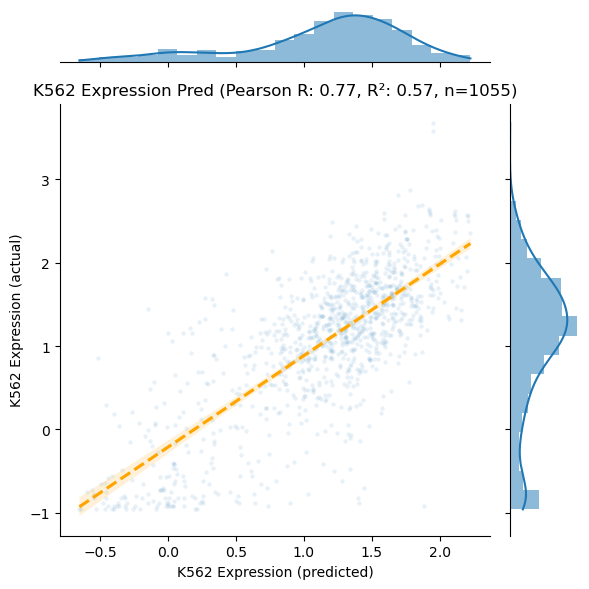

In [10]:
cell_line = 'K562' if not BOTH_CELL_LINES else 'K562/GM12878'
print(cell_line)
plot_predictions(predictions_filtered, cell_line=cell_line, pred_col='PredExpr', actual_col='ActualExpr')
plt.show()

In [11]:
if BOTH_CELL_LINES:
    plot_predictions(predictions_filtered[predictions_filtered['CellLine'] == 'K562'], cell_line='K562', pred_col='PredExpr', actual_col='ActualExpr')
    plot_predictions(predictions_filtered[predictions_filtered['CellLine'] == 'GM12878'], cell_line='GM12878', pred_col='PredExpr', actual_col='ActualExpr')

In [12]:
predictions_psi_filtered = None
binary_predictions = None
if HURDLE_SEPARATION:
    binary_predictions = predictions.copy()
    # convert all numbers that are not 1 to zero
    binary_predictions['PredPsi'] = np.where(binary_predictions['PredPsi'] == 1, "1", "0-0.99")
    binary_predictions['ActualPsi'] = np.where(binary_predictions['ActualPsi'] == 1, "1", "0-0.99")

    # predictions_psi_filtered = predictions[binary_predictions['ActualPsi'] != "1"].copy()
    predictions_psi_filtered = predictions[(predictions['PredPsi'] != 1) & (predictions['ActualPsi'] != 1)].copy()

In [13]:
predictions_psi_filtered

<Figure size 600x600 with 0 Axes>

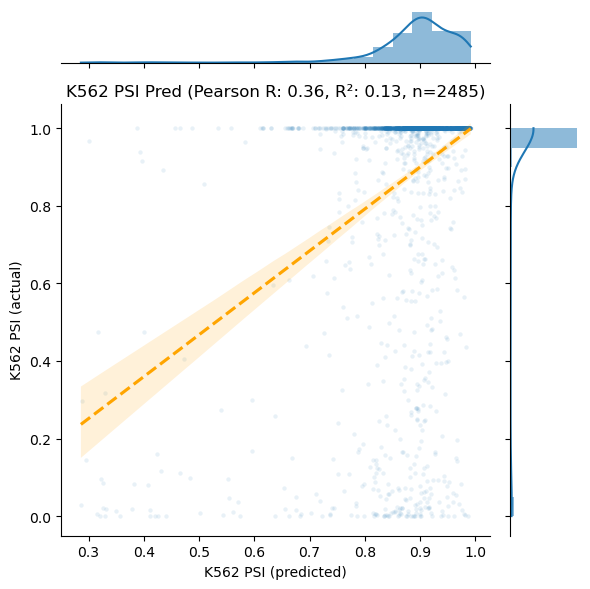

In [14]:
if binary_predictions is not None:
    plot_confusion_matrix(binary_predictions, cell_line='K562', pred_col='PredPsi', actual_col='ActualPsi')
    plt.show()

if predictions_psi_filtered is None:
    predictions_psi_filtered = predictions[predictions['gene_id'].isin(se_genes)] if FILTER_SE_GENES else predictions.copy()
plot_predictions(predictions_psi_filtered, cell_line='K562', pred_col='PredPsi', actual_col='ActualPsi')
plt.show()

In [15]:
if NORMALISED_SCORES:
    plot_predictions(predictions_filtered, cell_line='K562', pred_col='UncorrPredPsi', actual_col='UncorrActualPsi')
    plt.show()
    plot_predictions(predictions_filtered, cell_line='K562', pred_col='UncorrPredExpr', actual_col='UncorrActualExpr')
    plt.show()

## Check how similar predictions for the same genes are 

In [16]:
# filter for rows where gene_id appears more than once
predictions_multiple = predictions[predictions.duplicated(subset=['gene_id'], keep=False)]
predictions_multiple

,gene_id,PredExpr,ActualExpr,PredPsi,ActualPsi,fold_idx
2,ENSG00000064102,1.753818,1.707059,0.883961,1.000000,1
3,ENSG00000064102,1.703197,1.707059,0.887796,1.000000,1
4,ENSG00000064102,1.764012,1.707059,0.842362,1.000000,1
5,ENSG00000117533,1.855373,1.129690,0.913361,1.000000,1
6,ENSG00000117533,1.833878,1.129690,0.852350,1.000000,1
...,...,...,...,...,...,...
2477,ENSG00000149257,1.275417,1.830139,0.542694,0.003889,1
2479,ENSG00000106397,1.620831,1.317646,0.888424,1.000000,1
2480,ENSG00000106397,1.625397,1.317646,0.877622,1.000000,1
2481,ENSG00000106397,1.627074,1.317646,0.915886,1.000000,1


In [17]:
predictions_multiple['index'] = predictions_multiple.groupby('gene_id').cumcount()
predictions_multiple

/tmp/ipykernel_429769/27208789.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predictions_multiple['index'] = predictions_multiple.groupby('gene_id').cumcount()


,gene_id,PredExpr,ActualExpr,PredPsi,ActualPsi,fold_idx,index
2,ENSG00000064102,1.753818,1.707059,0.883961,1.000000,1,0
3,ENSG00000064102,1.703197,1.707059,0.887796,1.000000,1,1
4,ENSG00000064102,1.764012,1.707059,0.842362,1.000000,1,2
5,ENSG00000117533,1.855373,1.129690,0.913361,1.000000,1,0
6,ENSG00000117533,1.833878,1.129690,0.852350,1.000000,1,1
...,...,...,...,...,...,...,...
2477,ENSG00000149257,1.275417,1.830139,0.542694,0.003889,1,3
2479,ENSG00000106397,1.620831,1.317646,0.888424,1.000000,1,0
2480,ENSG00000106397,1.625397,1.317646,0.877622,1.000000,1,1
2481,ENSG00000106397,1.627074,1.317646,0.915886,1.000000,1,2


In [18]:
summary = (
    predictions_multiple
    .groupby('gene_id')['PredExpr']
    .agg(['min', 'max', 'mean'])
    .assign(range=lambda x: x['max'] - x['min'])
    .sort_values('mean', ascending=False)
    .reset_index()
)
summary

,gene_id,min,max,mean,range
0,ENSG00000136450,2.208196,2.233911,2.221053,0.025714
1,ENSG00000146842,2.189150,2.244702,2.216926,0.055552
2,ENSG00000173812,2.142483,2.232278,2.199661,0.089795
3,ENSG00000132912,2.179875,2.206691,2.193283,0.026816
4,ENSG00000214046,2.101324,2.245961,2.181946,0.144637
...,...,...,...,...,...
657,ENSG00000134765,-0.546305,-0.464340,-0.499659,0.081965
658,ENSG00000163082,-0.537497,-0.529953,-0.533725,0.007543
659,ENSG00000198156,-0.671564,-0.494735,-0.583150,0.176829
660,ENSG00000107282,-0.678417,-0.473453,-0.603099,0.204964


[W924 15:45:53.312062986 OperatorEntry.cpp:154] Warning: Warning only once for all operators,  other operators may also be overridden.
  Overriding a previously registered kernel for the same operator and the same dispatch key
  operator: aten::_validate_compressed_sparse_indices(bool is_crow, Tensor compressed_idx, Tensor plain_idx, int cdim, int dim, int nnz) -> ()
    registered at /pytorch/build/aten/src/ATen/RegisterSchema.cpp:6
  dispatch key: XPU
  previous kernel: registered at /pytorch/build/aten/src/ATen/RegisterCPU.cpp:30477
       new kernel: registered at /build/intel-pytorch-extension/build/Release/csrc/gpu/csrc/aten/generated/ATen/RegisterXPU.cpp:468 (function operator())


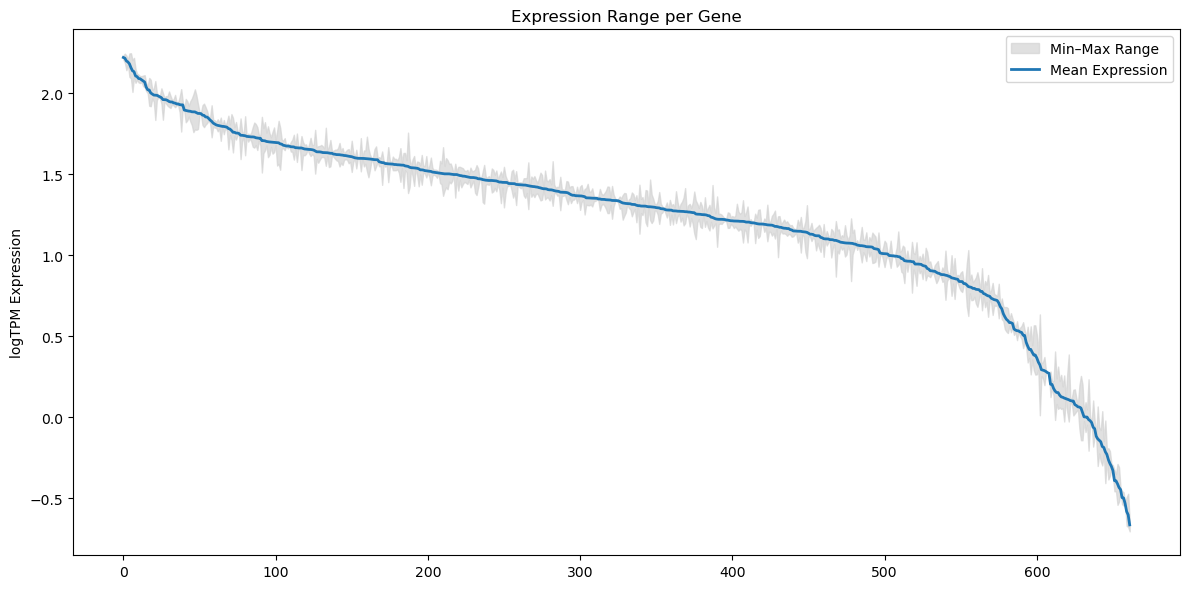

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(summary))

# Shaded area for min-max range
ax.fill_between(x, summary['min'], summary['max'], color='lightgray', alpha=0.7, label='Min–Max Range')

# Line for the mean
ax.plot(x, summary['mean'], linewidth=2, label='Mean Expression')

# Formatting
ax.set_ylabel("logTPM Expression")
ax.set_title("Expression Range per Gene")
ax.legend()
plt.tight_layout()
plt.show()

95th percentile of expression range: 0.26183952999999993


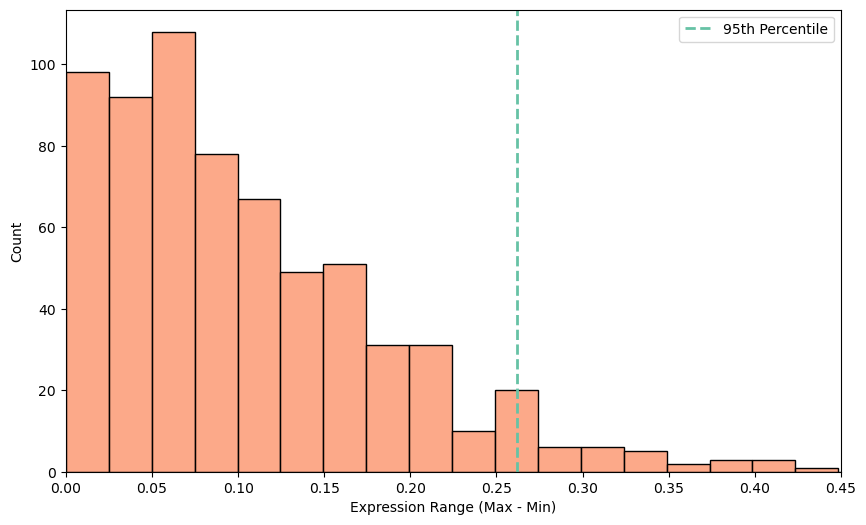

In [20]:
# plot the range as a KDE
palette = sns.color_palette("Set2")
plt.figure(figsize=(10, 6))
sns.histplot(summary['range'], color=palette[1], kde=False)
# vertical line for 99th percentile
percentile_99 = np.percentile(summary['range'], 95)
print(f"95th percentile of expression range: {percentile_99}")
plt.axvline(percentile_99, color=palette[0], linestyle='dashed', linewidth=2, label='95th Percentile')
plt.legend()
plt.xlim(0, 0.45)
plt.xlabel('Expression Range (Max - Min)')
plt.savefig("../images/expression_pred_range.png")
plt.show()

In [21]:
# pick the worst prediction for each gene and caclculate pearson r and r2
worst_predictions = predictions.copy()
worst_predictions['distance_to_actual'] = abs(worst_predictions['PredExpr'] - worst_predictions['ActualExpr'])
# for any gene that appears more than once, pick the row with the highest distance_to_actual
worst_predictions = worst_predictions.loc[worst_predictions.groupby('gene_id')['distance_to_actual'].idxmax()]

# calculate pearson r and r2
pearsonR, _ = stats.pearsonr(worst_predictions['PredExpr'], worst_predictions['ActualExpr'])
r2_value = r2_score(worst_predictions['ActualExpr'], worst_predictions['PredExpr'])
print(f"Worst predictions - Pearson R: {pearsonR:.2f}, R²: {r2_value:.2f}, n={len(worst_predictions)}")

Worst predictions - Pearson R: 0.74, R²: 0.53, n=1055


In [22]:
# get a standard deviation from the average predicted expression
std_dev = predictions_filtered['PredExpr'].std()
std_dev

0.6047008716103366

## Binary output

In [23]:
# remove rows where ActualPsi is > 0.2 and < 0.8
predictions_filtered = predictions[(predictions['ActualPsi'] <= 0.2) | (predictions['ActualPsi'] >= 0.8)].copy()
predictions_filtered

,gene_id,PredExpr,ActualExpr,PredPsi,ActualPsi,fold_idx
0,ENSG00000196388,1.397516,-0.823909,0.942808,1.0,1
1,ENSG00000164051,1.308474,1.109916,0.912360,1.0,1
2,ENSG00000064102,1.753818,1.707059,0.883961,1.0,1
3,ENSG00000064102,1.703197,1.707059,0.887796,1.0,1
4,ENSG00000064102,1.764012,1.707059,0.842362,1.0,1
...,...,...,...,...,...,...
2480,ENSG00000106397,1.625397,1.317646,0.877622,1.0,1
2481,ENSG00000106397,1.627074,1.317646,0.915886,1.0,1
2482,ENSG00000106397,1.589247,1.317646,0.885427,1.0,1
2483,ENSG00000134769,-0.361472,0.045323,0.976688,1.0,1


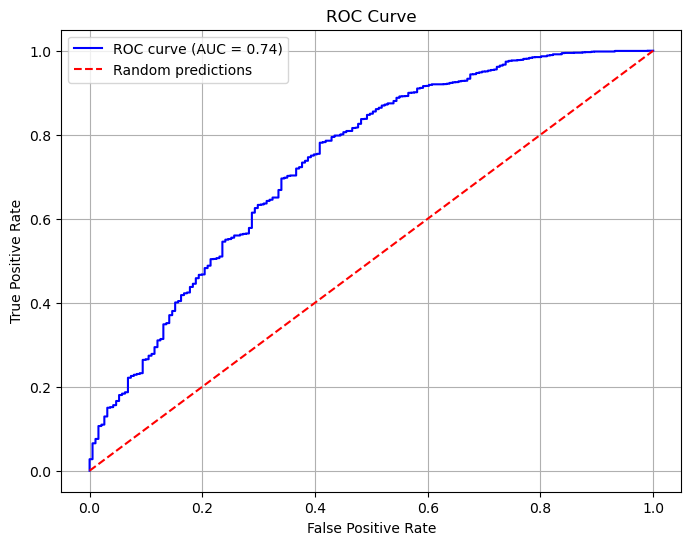

In [24]:
# binarize ActualPsi
predictions_filtered['BinarizedPsi'] = np.where(predictions_filtered['ActualPsi'] >= 0.5, 1, 0)
# plot ROC
fpr, tpr, thresholds = roc_curve(predictions_filtered['BinarizedPsi'], predictions_filtered['PredPsi'])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random predictions')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.grid()
plt.legend()
plt.show()

In [25]:
# print f1, accuracy, precision, recall
from sklearn.metrics import matthews_corrcoef, roc_auc_score, balanced_accuracy_score
predictions_filtered['BinarizedPsi'] = np.where(predictions_filtered['ActualPsi'] >= 0.5, 1, 0)
predictions_filtered['BinarizedPred'] = np.where(predictions_filtered['PredPsi'] >= 0.5, 1, 0)

mcc = matthews_corrcoef(predictions_filtered['BinarizedPsi'], predictions_filtered['BinarizedPred'])
roc_auc = roc_auc_score(predictions_filtered['BinarizedPsi'], predictions_filtered['PredPsi'])
balanced_acc = balanced_accuracy_score(predictions_filtered['BinarizedPsi'], predictions_filtered['BinarizedPred'])
f1_metric = f1_score(predictions_filtered['BinarizedPsi'], predictions_filtered['BinarizedPred'])
print(f"MCC: {mcc:.2f}, ROC AUC: {roc_auc:.2f}, Balanced Accuracy: {balanced_acc:.2f}, F1 Score: {f1_metric:.2f}")

MCC: 0.28, ROC AUC: 0.74, Balanced Accuracy: 0.56, F1 Score: 0.96


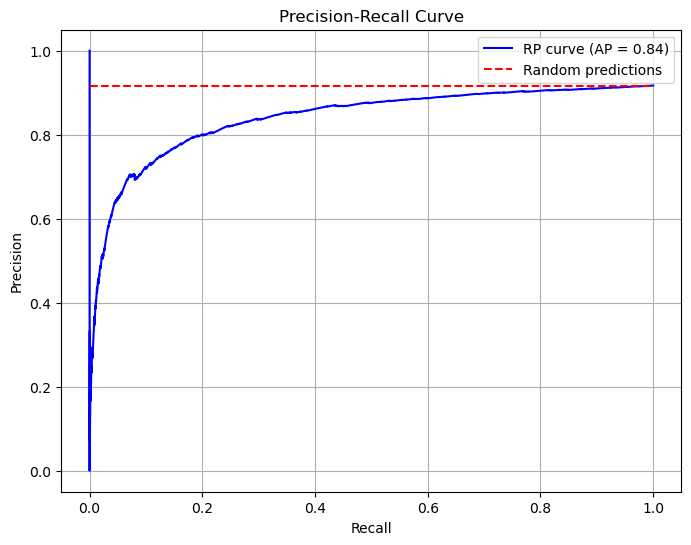

In [26]:
# binarize ActualPsi
# plot Precision recall curve
precision, recall, thresholds = precision_recall_curve(predictions_filtered['BinarizedPsi'], predictions_filtered['PredPsi'] * -1)
average_precision = average_precision_score(predictions_filtered['BinarizedPsi'], predictions_filtered['PredPsi'] * -1)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', label=f'RP curve (AP = {average_precision:.2f})')
plt.hlines(sum(predictions_filtered['BinarizedPsi']) / len(predictions_filtered['BinarizedPsi']), 0, 1, colors='red', linestyles='dashed', label='Random predictions')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid()
plt.legend()
plt.show()

In [27]:
predictions_filtered

,gene_id,PredExpr,ActualExpr,PredPsi,ActualPsi,fold_idx,BinarizedPsi,BinarizedPred
0,ENSG00000196388,1.397516,-0.823909,0.942808,1.0,1,1,1
1,ENSG00000164051,1.308474,1.109916,0.912360,1.0,1,1,1
2,ENSG00000064102,1.753818,1.707059,0.883961,1.0,1,1,1
3,ENSG00000064102,1.703197,1.707059,0.887796,1.0,1,1,1
4,ENSG00000064102,1.764012,1.707059,0.842362,1.0,1,1,1
...,...,...,...,...,...,...,...,...
2480,ENSG00000106397,1.625397,1.317646,0.877622,1.0,1,1,1
2481,ENSG00000106397,1.627074,1.317646,0.915886,1.0,1,1,1
2482,ENSG00000106397,1.589247,1.317646,0.885427,1.0,1,1,1
2483,ENSG00000134769,-0.361472,0.045323,0.976688,1.0,1,1,1


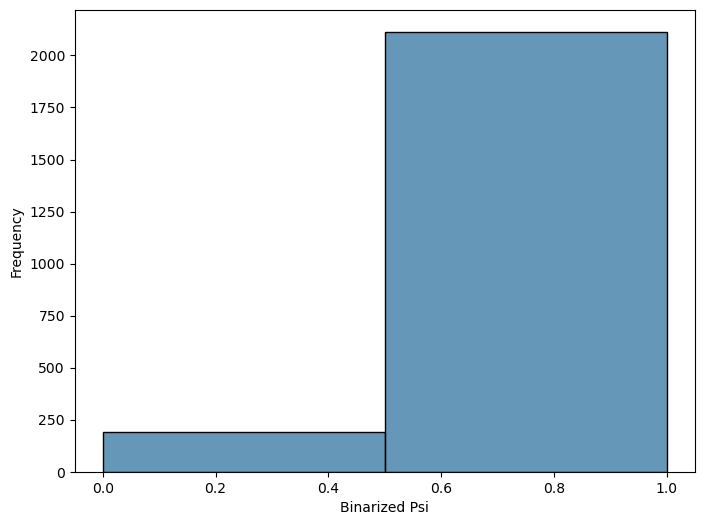

In [28]:
# plot distribution of binary samples as hist plot
plt.figure(figsize=(8, 6))
sns.histplot(predictions_filtered['BinarizedPsi'], bins=2, color='#3274A1', kde=False)
plt.xlabel('Binarized Psi')
plt.ylabel('Frequency')
plt.show()

## Check predictions of AR vs SE genes in expression

In [29]:
predictions_split = predictions.copy()
se_events = pd.read_csv('../data/psi_response.csv')
se_events = se_events[se_events['event_id'].str.contains(';SE:')]
se_genes = set(se_events['gene_id'].unique())

predictions_split['SE gene'] = predictions_split['gene_id'].apply(lambda x: x in se_genes)
predictions_split['AR gene'] = ~predictions_split['SE gene']
predictions_split

,gene_id,PredExpr,ActualExpr,PredPsi,ActualPsi,fold_idx,SE gene,AR gene
0,ENSG00000196388,1.397516,-0.823909,0.942808,1.0,1,False,True
1,ENSG00000164051,1.308474,1.109916,0.912360,1.0,1,False,True
2,ENSG00000064102,1.753818,1.707059,0.883961,1.0,1,False,True
3,ENSG00000064102,1.703197,1.707059,0.887796,1.0,1,False,True
4,ENSG00000064102,1.764012,1.707059,0.842362,1.0,1,False,True
...,...,...,...,...,...,...,...,...
2480,ENSG00000106397,1.625397,1.317646,0.877622,1.0,1,False,True
2481,ENSG00000106397,1.627074,1.317646,0.915886,1.0,1,False,True
2482,ENSG00000106397,1.589247,1.317646,0.885427,1.0,1,False,True
2483,ENSG00000134769,-0.361472,0.045323,0.976688,1.0,1,False,True


In [30]:
summary['Gene type'] = summary['gene_id'].apply(lambda x: 'SE' if x in se_genes else 'AR')
summary

,gene_id,min,max,mean,range,Gene type
0,ENSG00000136450,2.208196,2.233911,2.221053,0.025714,AR
1,ENSG00000146842,2.189150,2.244702,2.216926,0.055552,SE
2,ENSG00000173812,2.142483,2.232278,2.199661,0.089795,SE
3,ENSG00000132912,2.179875,2.206691,2.193283,0.026816,SE
4,ENSG00000214046,2.101324,2.245961,2.181946,0.144637,SE
...,...,...,...,...,...,...
657,ENSG00000134765,-0.546305,-0.464340,-0.499659,0.081965,AR
658,ENSG00000163082,-0.537497,-0.529953,-0.533725,0.007543,AR
659,ENSG00000198156,-0.671564,-0.494735,-0.583150,0.176829,AR
660,ENSG00000107282,-0.678417,-0.473453,-0.603099,0.204964,AR


In [31]:
# average shift for Se and AR
summary.groupby('Gene type')['range'].mean()

Gene type
AR    0.096421
SE    0.112718
Name: range, dtype: float64

In [32]:
# one sided mann-whitney U test -> are SE events associated with a larger expression range than AR events?
se_ranges = summary[summary['Gene type'] == 'SE']['range']
ar_ranges = summary[summary['Gene type'] == 'AR']['range']
u_stat, p_value = stats.mannwhitneyu(se_ranges, ar_ranges, alternative='two-sided')
print(f"Mann-Whitney U test: U-statistic = {u_stat}, p-value = {p_value}")

Mann-Whitney U test: U-statistic = 63554.0, p-value = 6.478328976786665e-05


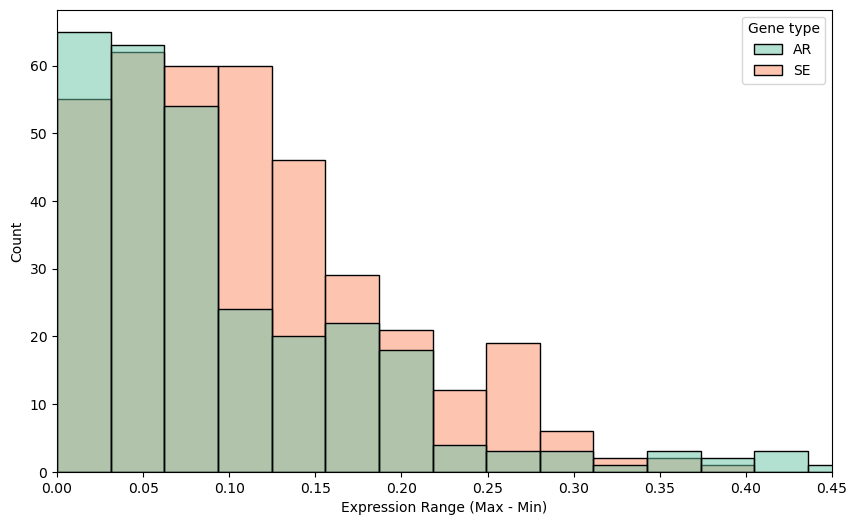

In [33]:
# sns.set_theme(style="whitegrid")
palette = sns.color_palette("Set2", n_colors=2)
plt.figure(figsize=(10, 6))
sns.histplot(
    data=summary[summary["Gene type"].isin(["SE", "AR"])],
    x="range", hue="Gene type", bins=20, palette=palette,
)
plt.xlim(0, 0.45)
plt.xlabel('Expression Range (Max - Min)')
plt.savefig("../images/expression_pred_range.png")
plt.show()

<Figure size 600x600 with 0 Axes>

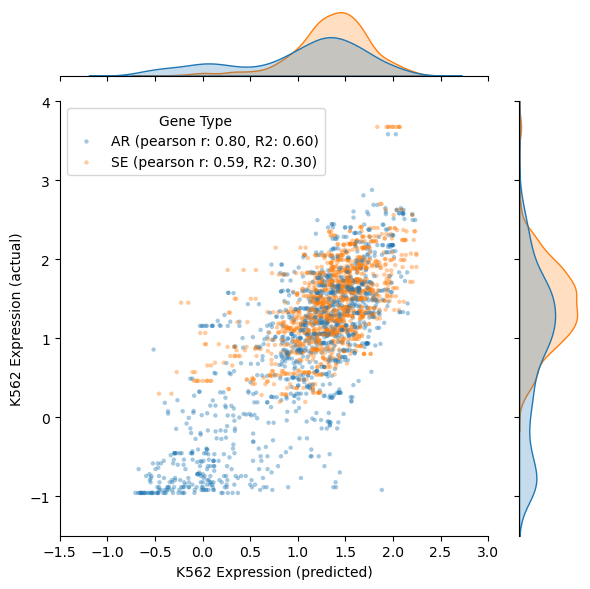

In [34]:
# visualise predictions of expr by SE gene (also calculate metrics by SE gene)

se_preds = predictions_split[predictions_split['SE gene'] == True]
ar_preds = predictions_split[predictions_split['SE gene'] == False]
pearsonR_se, _ = stats.pearsonr(se_preds['PredExpr'], se_preds['ActualExpr'])
pearsonR_ar, _ = stats.pearsonr(ar_preds['PredExpr'], ar_preds['ActualExpr'])
r2_se = r2_score(se_preds['ActualExpr'], se_preds['PredExpr'])
r2_ar = r2_score(ar_preds['ActualExpr'], ar_preds['PredExpr'])
prediction_task = 'Expression'

predictions_split['Gene Type'] = predictions_split['SE gene'].replace({True: f'SE (pearson r: {pearsonR_se:.2f}, R2: {r2_se:.2f})', False: f'AR (pearson r: {pearsonR_ar:.2f}, R2: {r2_ar:.2f})'})

plt.figure(figsize=(6,6))
ax = sns.jointplot(
    data=predictions_split,
    x='PredExpr',
    y='ActualExpr',
    hue='Gene Type',
    kind = 'scatter',
    joint_kws={'marker':'o', 's':10, 'alpha':0.4, 'linewidth':0},
)

plt.ylabel(f'{cell_line} {prediction_task} (actual)')
plt.xlabel(f'{cell_line} {prediction_task} (predicted)')
plt.ylim(-1.5,4)
plt.xlim(-1.5,3)
plt.tight_layout()
plt.show()

In [35]:
ar_preds

,gene_id,PredExpr,ActualExpr,PredPsi,ActualPsi,fold_idx,SE gene,AR gene
0,ENSG00000196388,1.397516,-0.823909,0.942808,1.0,1,False,True
1,ENSG00000164051,1.308474,1.109916,0.912360,1.0,1,False,True
2,ENSG00000064102,1.753818,1.707059,0.883961,1.0,1,False,True
3,ENSG00000064102,1.703197,1.707059,0.887796,1.0,1,False,True
4,ENSG00000064102,1.764012,1.707059,0.842362,1.0,1,False,True
...,...,...,...,...,...,...,...,...
2480,ENSG00000106397,1.625397,1.317646,0.877622,1.0,1,False,True
2481,ENSG00000106397,1.627074,1.317646,0.915886,1.0,1,False,True
2482,ENSG00000106397,1.589247,1.317646,0.885427,1.0,1,False,True
2483,ENSG00000134769,-0.361472,0.045323,0.976688,1.0,1,False,True


/tmp/ipykernel_429769/1385560189.py:2: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearsonR_ar, _ = stats.pearsonr(ar_preds['PredPsi'], ar_preds['ActualPsi'])


<Figure size 600x600 with 0 Axes>

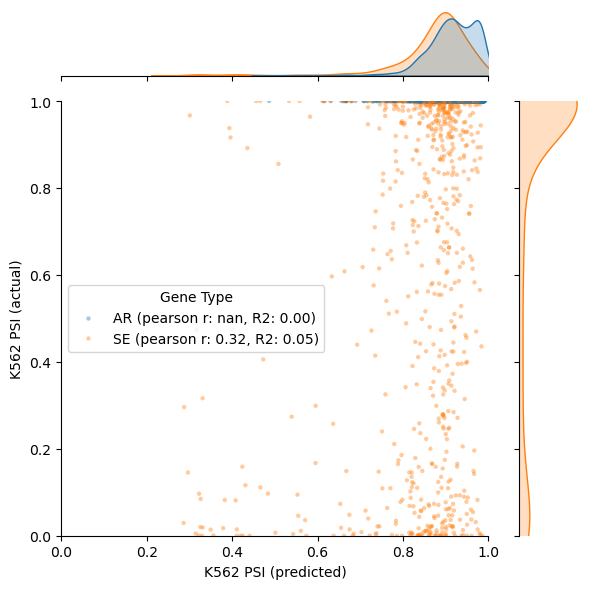

In [36]:
pearsonR_se, _ = stats.pearsonr(se_preds['PredPsi'], se_preds['ActualPsi'])
pearsonR_ar, _ = stats.pearsonr(ar_preds['PredPsi'], ar_preds['ActualPsi'])
r2_se = r2_score(se_preds['ActualPsi'], se_preds['PredPsi'])
r2_ar = r2_score(ar_preds['ActualPsi'], ar_preds['PredPsi'])
prediction_task = 'PSI'

predictions_split['Gene Type'] = predictions_split['SE gene'].replace({True: f'SE (pearson r: {pearsonR_se:.2f}, R2: {r2_se:.2f})', False: f'AR (pearson r: {pearsonR_ar:.2f}, R2: {r2_ar:.2f})'})

plt.figure(figsize=(6,6))
ax = sns.jointplot(
    data=predictions_split,
    x='PredPsi',
    y='ActualPsi',
    hue='Gene Type',
    kind = 'scatter',
    joint_kws={'marker':'o', 's':10, 'alpha':0.4, 'linewidth':0},
)
plt.ylim(0, 1)
plt.xlim(0, 1)

plt.ylabel(f'{cell_line} {prediction_task} (actual)')
plt.xlabel(f'{cell_line} {prediction_task} (predicted)')
plt.tight_layout()
plt.show()

In [37]:
binary_predictions = predictions_psi_filtered.copy()
# remove rows where ActualPsi is > 0.2 and < 0.8
binary_predictions = binary_predictions[(binary_predictions['ActualPsi'] <= 0.2) | (binary_predictions['ActualPsi'] >= 0.8)].copy()
binary_predictions['ActualPsi'] = np.where(binary_predictions['ActualPsi'] > 0.5, 1, 0)

roc_auc = roc_auc_score(binary_predictions['ActualPsi'], binary_predictions['PredPsi'])
binary_predictions['PredPsi'] = np.where(binary_predictions['PredPsi'] > 0.5, 1, 0)
mcc = matthews_corrcoef(binary_predictions['ActualPsi'], binary_predictions['PredPsi'])
balanced_acc = balanced_accuracy_score(binary_predictions['ActualPsi'], binary_predictions['PredPsi'])
f1_metric = f1_score(binary_predictions['ActualPsi'], binary_predictions['PredPsi'])
print(f"MCC: {mcc:.2f}, ROC AUC: {roc_auc:.2f}, Balanced Accuracy: {balanced_acc:.2f}, F1 Score: {f1_metric:.2f}")

MCC: 0.28, ROC AUC: 0.74, Balanced Accuracy: 0.56, F1 Score: 0.96


In [38]:
# look at binary distribution of PSI for AR and SE separately
binary_preds_se = se_preds.copy()
# remove rows where ActualPsi is > 0.2 and < 0.8
binary_preds_se = binary_preds_se[(binary_preds_se['ActualPsi'] <= 0.2) | (binary_preds_se['ActualPsi'] >= 0.8)].copy()
#binary_preds_se['PredPsi'] = np.where(binary_preds_se['PredPsi'] > 0.5, 1, 0)
binary_preds_se['ActualPsi'] = np.where(binary_preds_se['ActualPsi'] > 0.5, 1, 0)
binary_preds_ar = ar_preds.copy()
#binary_preds_ar['PredPsi'] = np.where(binary_preds_ar['PredPsi'] > 0.5, 1, 0)
binary_preds_ar['ActualPsi'] = np.where(binary_preds_ar['ActualPsi'] > 0.5, 1, 0)

In [39]:
# calculate MCC, balanced acc, roc auc, f1 for both
roc_auc_se = roc_auc_score(binary_preds_se['ActualPsi'], binary_preds_se['PredPsi'])
binary_preds_se['PredPsi'] = np.where(binary_preds_se['PredPsi'] > 0.5, 1, 0)
mcc_se = matthews_corrcoef(binary_preds_se['ActualPsi'], binary_preds_se['PredPsi'])
balanced_acc_se = balanced_accuracy_score(binary_preds_se['ActualPsi'], binary_preds_se['PredPsi'])
f1_metric_se = f1_score(binary_preds_se['ActualPsi'], binary_preds_se['PredPsi'])
print(f"SE genes - MCC: {mcc_se:.2f}, ROC AUC: {roc_auc_se:.2f}, Balanced Accuracy: {balanced_acc_se:.2f}, F1 Score: {f1_metric_se:.2f}")

SE genes - MCC: 0.26, ROC AUC: 0.68, Balanced Accuracy: 0.56, F1 Score: 0.91


In [40]:
roc_auc_ar = roc_auc_score(binary_preds_ar['ActualPsi'], binary_preds_ar['PredPsi'])
binary_preds_ar['PredPsi'] = np.where(binary_preds_ar['PredPsi'] > 0.5, 1, 0)
mcc_ar = matthews_corrcoef(binary_preds_ar['ActualPsi'], binary_preds_ar['PredPsi'])
balanced_acc_ar = balanced_accuracy_score(binary_preds_ar['ActualPsi'], binary_preds_ar['PredPsi'])
f1_metric_ar = f1_score(binary_preds_ar['ActualPsi'], binary_preds_ar['PredPsi'])
print(f"AR genes - MCC: {mcc_ar:.2f}, ROC AUC: {roc_auc_ar:.2f}, Balanced Accuracy: {balanced_acc_ar:.2f}, F1 Score: {f1_metric_ar:.2f}")

AR genes - MCC: 0.00, ROC AUC: nan, Balanced Accuracy: 1.00, F1 Score: 1.00


/home/elias/.conda/envs/EPInformer_env/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/elias/.conda/envs/EPInformer_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
